# Library comparisson with BitBirch

Authors: Kenneth Lopez-Perez (klopezperez@ufl.edu) and Ramon Miranda-Quintana (quintana@chem.ufl.edu)

This notebook shows examples on how to compare two libraries to identify regions of the chemical space they have in common, and what regions they do not share.


In [1]:
from iChem.libchem import LibChem, LibComparison
from iChem.visualization import *
import numpy as np
np.random.seed(42)

Here we are going to create LibChem objects for each of the libraries we are going to compare. We are going to load the smiles and generate ECFP4 fingerprints to represent the molecules. 

We are going to compare mcule libraries. For download of this libraries please refer to https://mcule.com/database/.

In [2]:
Lib1 = LibChem()
Lib1.load_smiles('../tests/data/mcule_macrocycles.smi')
Lib1.generate_fingerprints(fp_type='ECFP4', n_bits=2048)

Lib2 = LibChem()
Lib2.load_smiles('../tests/data/mcule_natural_like_products.smi')
Lib2.generate_fingerprints(fp_type='ECFP4', n_bits=2048)

Lib3 = LibChem()
Lib3.load_smiles('../tests/data/mcule_natural_products_derivatives.smi')
Lib3.generate_fingerprints(fp_type='ECFP4', n_bits=2048)


Let's check the size of these libraries.

In [3]:
print('Library 1 molecules:', Lib1.n_molecules)
print('Library 2 molecules:', Lib2.n_molecules)
print('Library 3 molecules:', Lib3.n_molecules)

Library 1 molecules: 163427
Library 2 molecules: 178992
Library 3 molecules: 109173


Now, let's check the average similarity (iSIM) of each of these databases.

In [4]:
print(f'iSIM library 1: {Lib1.get_iSIM():.4f}')
print(f'iSIM library 2: {Lib2.get_iSIM():.4f}')
print(f'iSIM library 3: {Lib3.get_iSIM():.4f}')

iSIM library 1: 0.1714
iSIM library 2: 0.1126
iSIM library 3: 0.1284


Now, we are going to check the standard deviation of the similarities (iSIM-sigma).

In [5]:
print(f'iSIM-sigma library 1: {Lib1.get_iSIM_sigma():.4f}')
print(f'iSIM-sigma library 2: {Lib2.get_iSIM_sigma():.4f}')
print(f'iSIM-sigma library 3: {Lib3.get_iSIM_sigma():.4f}')

iSIM-sigma library 1: 0.0727
iSIM-sigma library 2: 0.0484
iSIM-sigma library 3: 0.0523


Now let's do the clustering of each of the libraries and get how many clusters each one has. Some considerations:

- Note that an automatic threshold is used if `None` is indicated, this is iSIM + 3.5 iSIM-sigma. User can use a different threshold if they want to, but it needs to be indicated. 

- The branching factor is set as default to 1024, if libraries are larger than 1 million, user might want to increase the branching factor to consume less memory and get better results. 

- A default reclustering is also set as default to recuperate some singletons that might've not been clustered because of the initial tree structure, this step uses an extrathreshold of one iSIM-sigma, to prevent the formation of low quality clusters. Users have the option of not doing the reclustering step.

In [6]:
Lib1.cluster(threshold=None,
             branching_factor=1024,
             recluster=True)
Lib2.cluster()
Lib3.cluster()

To realize memory, we can save only the fingerprints of the medoids and samples we'll use

In [7]:
Lib1.save_cluster_medoids()
Lib2.save_cluster_medoids()
Lib3.save_cluster_medoids()

Lib1.save_cluster_samples(n_samples=6000)
Lib2.save_cluster_samples(n_samples=6000)
Lib3.save_cluster_samples(n_samples=6000)

Lib1.empty_fps()
Lib2.empty_fps()
Lib3.empty_fps()

Let's check how many clusters were found. With the following method, one can get the fingerprints and SMILES of the medoids of each cluster. 

In [8]:
print('Number of medoids library 1:', len(Lib1.get_cluster_medoids(return_smiles=False)))
print('Number of medoids library 2:', len(Lib2.get_cluster_medoids(return_smiles=False)))
print('Number of medoids library 3:', len(Lib3.get_cluster_medoids(return_smiles=False)))

Number of medoids library 1: 1122
Number of medoids library 2: 5554
Number of medoids library 3: 2982


## Library comparison

Now we are going to compare the libraries that we created and clustered above. For this we are going to use the `LibComparison` class. First, we gotta add the libraries to the instance. 

In [9]:
CompLib = LibComparison()
CompLib.add_library(Lib1, 'Macrocycles')
CompLib.add_library(Lib2, 'LikeProducts')
CompLib.add_library(Lib3, 'Derivatives')

Now we are going to compare the medoids between each pair of libraries. We are going to do the pairwise comparisons between medoids of two libraries, and then get the maximum similarity for each one, and then get the average. The higher the value, the more similar the two libraries are.

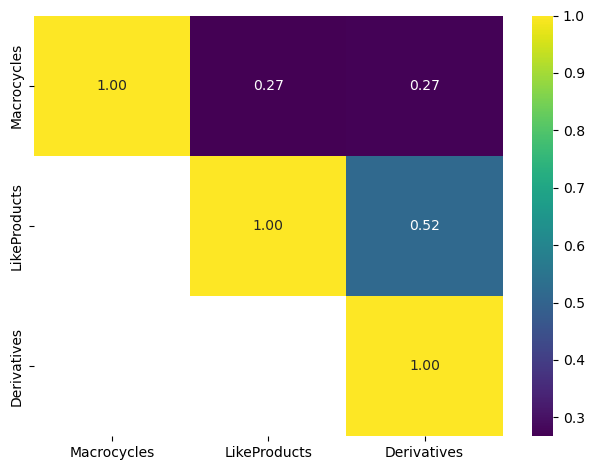

In [10]:
sims_results = CompLib.compare_medoids_heatmap(methodology='MaxSum')

As expected, the Natural-Like Products and the Natural Product Derivatives are more similar between each other than with the Macrocyles libraries.

We also included a way of calculating the average similarity if the medoids of the two libraries are combined together, this we called intra-iSIM. However, as you can see the values below they are not as informative, one of the main reason being that the averag similarities for ECFP4 are so low and have low standard deviation, making it a not convenient way of comparing libraries.

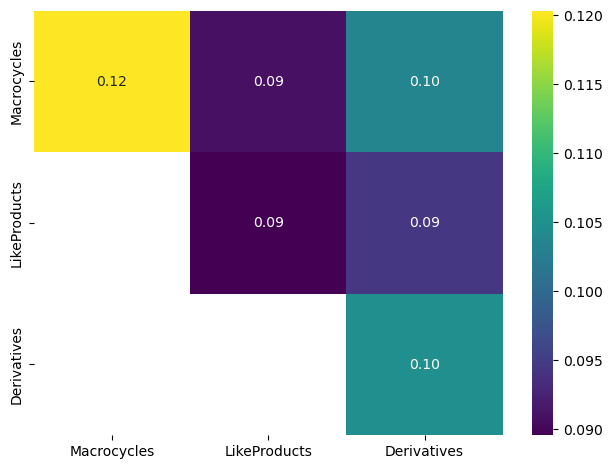

In [11]:
sims_results = CompLib.compare_medoids_heatmap(methodology='intraiSIM')

Another way we thought could give some information was the use of the average similarity between the medoids of one library to the other (excluiding the comparisons within molecules of each library). We called this inter-iSIM. However, it is not as informative as well, it suffers from the same cons as intra-iSIM.

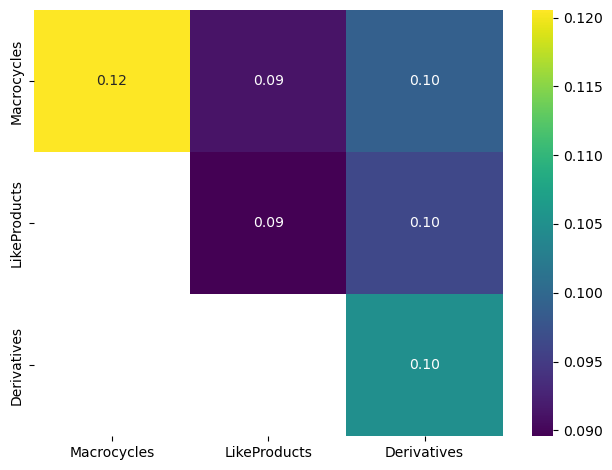

In [12]:
sims_results = CompLib.compare_medoids_heatmap(methodology='interiSIM')

From this section we conclude that is more informative to use the MaxSum of the medoids. However, this operation might be only useful for instances where the number of medoids (clusters) is low. The pairwise comparison of the medoids scales quadratically, making it not that useful for ultra-large libraries. For this reason we propose other methods in the following section.

## BitBirch clustering based strategies

Now, to address the comparison on a more local level, we are going to cluster the medoids from each library together. In this way we can get what sectors of chemical space they share and which are exclusive to one of the libraries.

To do the clustering, we will use the highest threshold of the individual libraries, to prevent the formation of lower quality clusters than the initial ones.

In [13]:
print(CompLib.libraries['Macrocycles'].threshold)
print(CompLib.libraries['LikeProducts'].threshold)
print(CompLib.libraries['Derivatives'].threshold)

0.42585043664120653
0.2818716636124799
0.3115604508755774


### Medoid-based clustering

With the following method, we can get the counts and mapping of the different types of clusters in terms of membership of the libraries. One can indicate with lib_names which libraries are going to be compared. If not indicated, all the loaded libraries will be compared. 

In [16]:
CompLib.cluster_libraries(methodology='medoids', verbose=True)
counts, mapping = CompLib.cluster_classification_counts(lib_names=['Macrocycles','LikeProducts', 'Derivatives']) # One can indicate which )

Number of medoids in Library Macrocycles: 1122
Number of medoids in Library LikeProducts: 5554
Number of medoids in Library Derivatives: 2982
Total number of medoids: 9658
Using clustering threshold: 0.4259


In [17]:
counts

{'LikeProducts+Macrocycles': 61,
 'Macrocycles': 730,
 'Derivatives+LikeProducts': 1212,
 'LikeProducts': 3215,
 'Derivatives+LikeProducts+Macrocycles': 38,
 'Derivatives+Macrocycles': 16,
 'Derivatives': 1209}

The mapping gives you the cluster number that correspond to each catedory, so for example in the next cell we will see the clsuters that have molecules from Natural Products Derivatives and Macrocycles

In [18]:
mapping['Derivatives+Macrocycles']

[94,
 204,
 206,
 300,
 355,
 513,
 580,
 757,
 802,
 940,
 980,
 1106,
 1148,
 1406,
 1478,
 1736]

We can analyze the compositon of the clusters, here we show a pie chart with the proportion by each of the categories. 

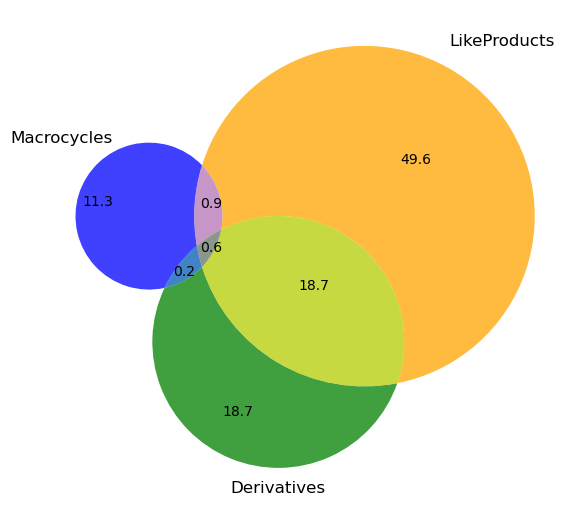

In [19]:
CompLib.venn_diagram_composition()

Here we show the populations of each cluster color-coded by the membership of each library in each cluster. User can define the number of top clusters to include in the plot.

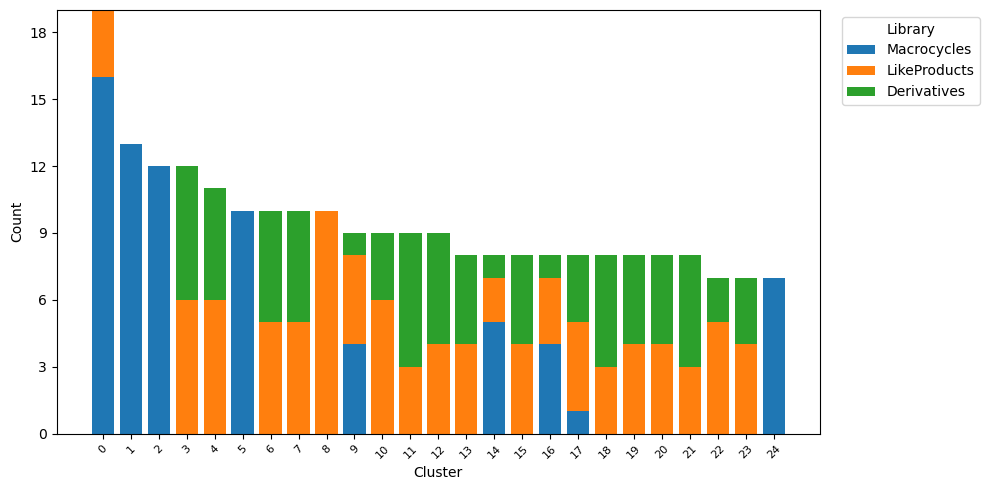

In [20]:
CompLib.plot_cluster_composition(lib_names=['Macrocycles','LikeProducts', 'Derivatives'],
                                 top=25)

We can also visualize to see if the clustering and chemical space comparison makes sense. For example, the largest cluster with molecules from the 3 libraries, we can visualize the structures and see if they indeed correspond to a shared chemical space. (Cluster number may change due to randomization in the clustering of the combined libraries)

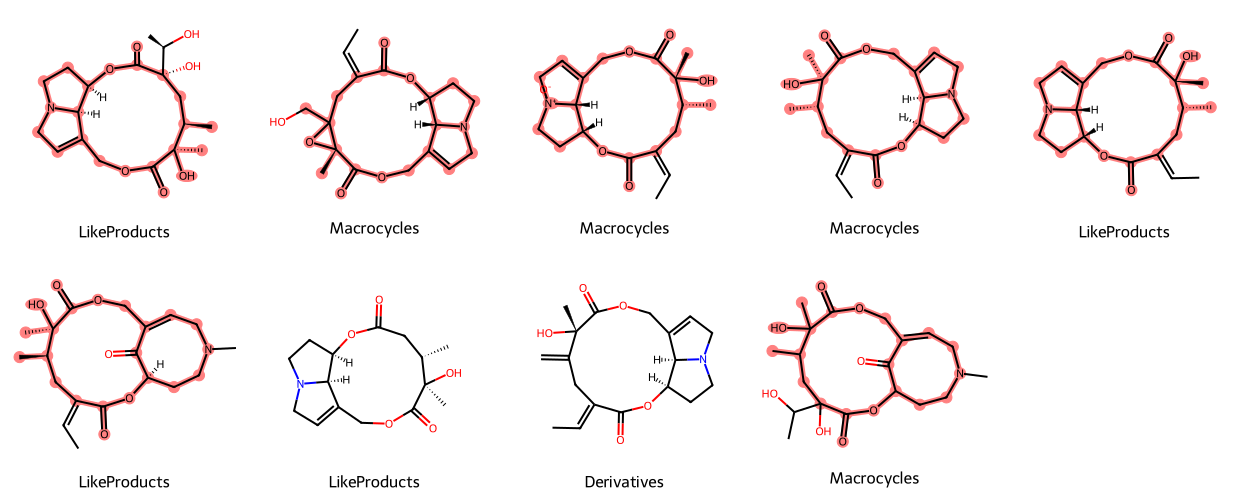

In [21]:
CompLib.cluster_visualization(cluster_number=9)

Now, let's inspect only clusters that have only molecules from one library. Let's check cluster 1.

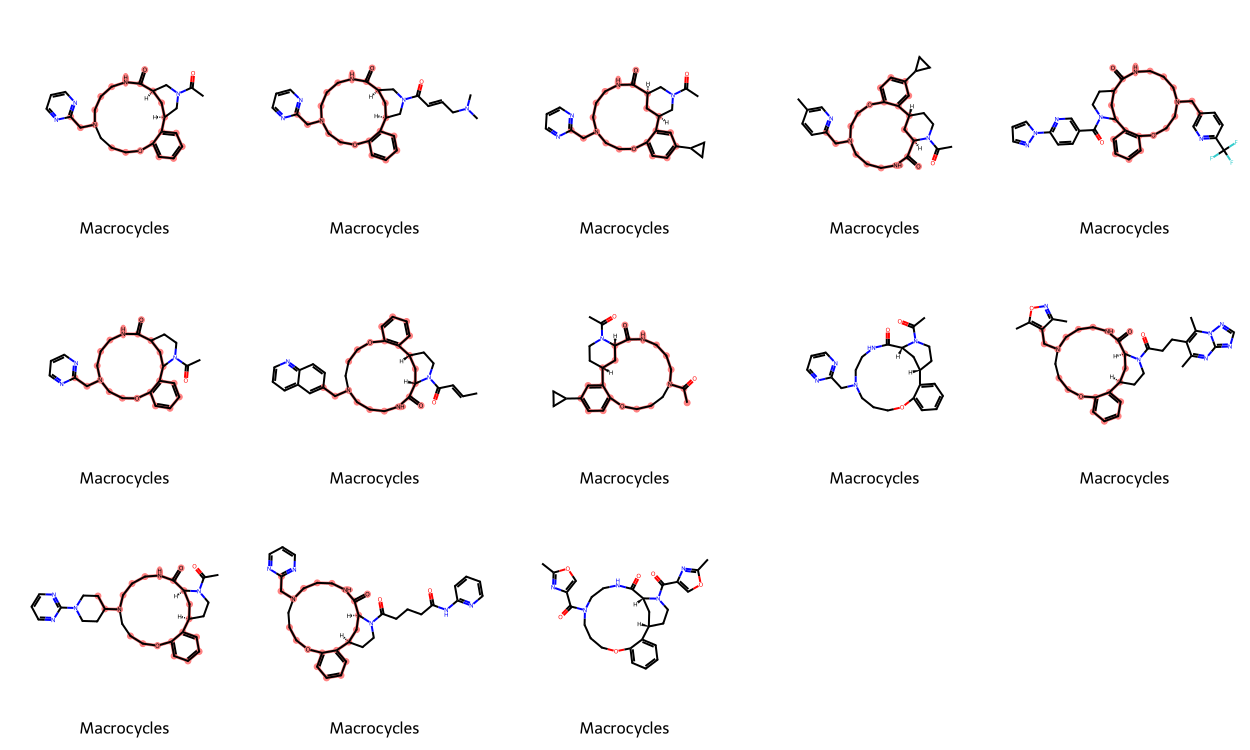

In [22]:
CompLib.cluster_visualization(cluster_number=1)

We can also compare certaing libraries and not all we added. We can compare the three possible pairs and see if we get similar results to when we do the three at the same time.

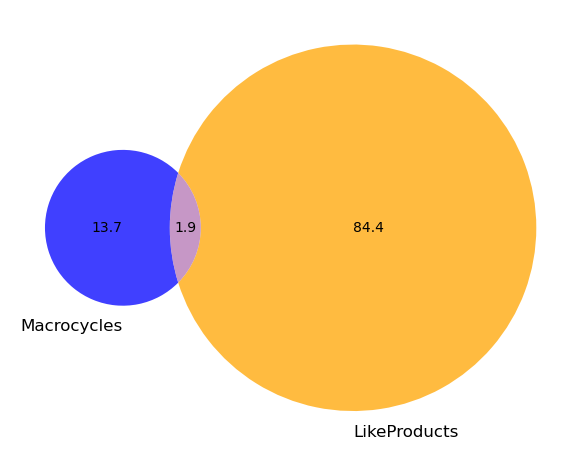

In [23]:
CompLib.cluster_libraries(methodology='medoids',
                         lib_names=['Macrocycles','LikeProducts'])
CompLib.venn_diagram_composition(lib_names=['Macrocycles','LikeProducts'])

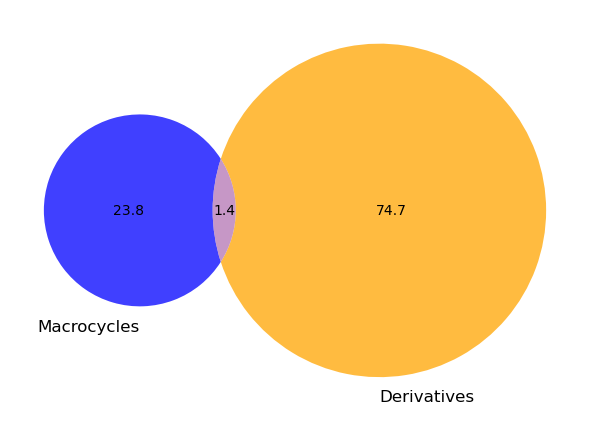

In [24]:
CompLib.cluster_libraries(methodology='medoids',
                         lib_names=['Macrocycles','Derivatives'])
CompLib.venn_diagram_composition(lib_names=['Macrocycles','Derivatives'])

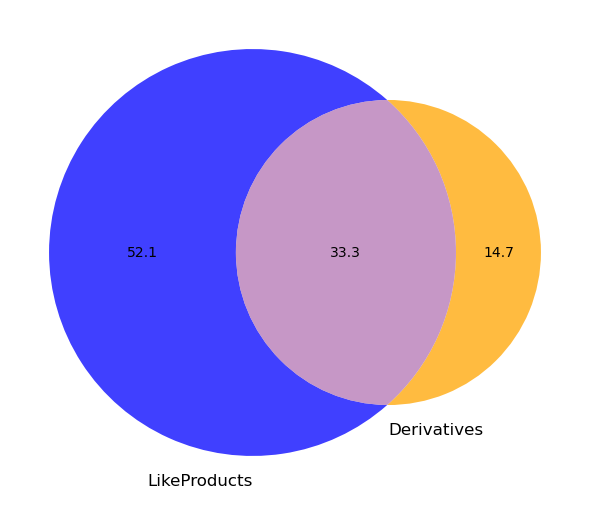

In [25]:
CompLib.cluster_libraries(methodology='medoids',
                         lib_names=['LikeProducts','Derivatives'])
CompLib.venn_diagram_composition(lib_names=['LikeProducts','Derivatives'])

### Sample-based clustering

For instances where the number of medoids is disproportioned, we propose a way to sample from the clusters that allows the same number of molecules per library. In this way, a larger library will not "overtake" the clustering. This methods samples the medoids first and then samples from the clusters taking into consideration the proportion the total cluster membership represents with respect of the total of number of molecules in the library. Priority is given to the larger clusters. For more details consult the manuscript. 

This methodology is called `samples`.

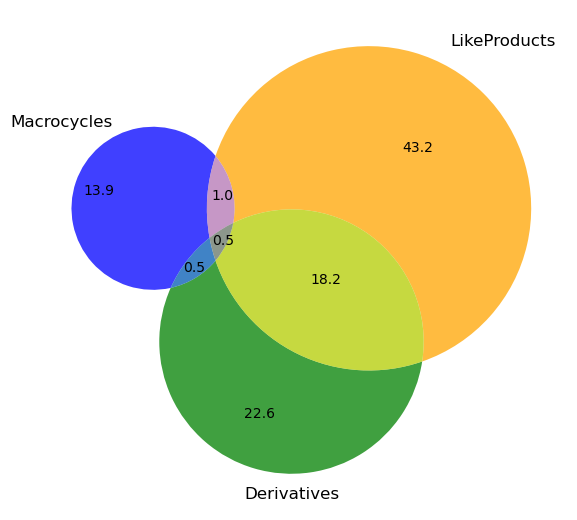

In [26]:
CompLib.cluster_libraries(methodology='samples',
                         lib_names=['Macrocycles','LikeProducts', 'Derivatives'],
                         n_samples=6000) # We pick a number that is larger than the largest number of medoids
CompLib.venn_diagram_composition(lib_names=['Macrocycles','LikeProducts', 'Derivatives'])

We can notice that the proportion are quite similar to the ones obtained with `medoids`. We recommend this only in instances where the difference in the number of medoids exceeds one or two orders of magnitude.

We can compare all the pairs of libraries to see if the results make sense. 

Number of sampled mols in Library Macrocycles: 6000
Number of sampled mols in Library LikeProducts: 6000
Total number of sampled mols: 12000
Using clustering threshold: 0.4259


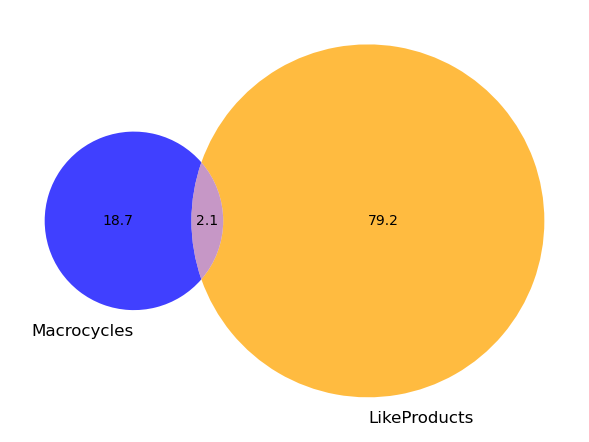

In [27]:
CompLib.cluster_libraries(methodology='samples',
                         lib_names=['Macrocycles','LikeProducts'],
                         n_samples=6000,
                         verbose=True) # We pick a number that is larger than the largest number of medoids
CompLib.venn_diagram_composition(lib_names=['Macrocycles','LikeProducts'])

Number of sampled mols in Library Macrocycles: 6000
Number of sampled mols in Library Derivatives: 6000
Total number of sampled mols: 12000
Using clustering threshold: 0.4259


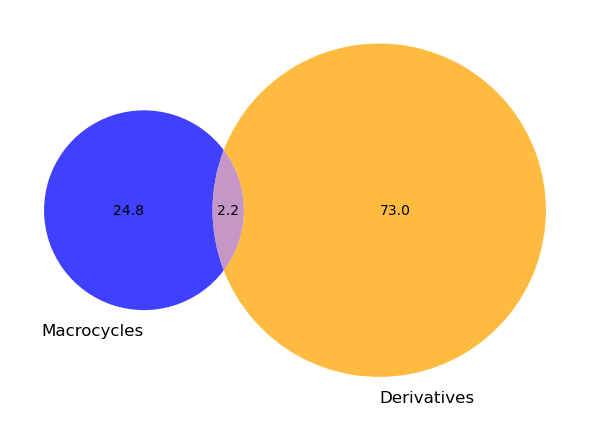

In [28]:
CompLib.cluster_libraries(methodology='samples',
                         lib_names=['Macrocycles','Derivatives'],
                         n_samples=6000,
                         verbose=True) # We pick a number that is larger than the largest number of medoids
CompLib.venn_diagram_composition(lib_names=['Macrocycles','Derivatives'])

Number of sampled mols in Library LikeProducts: 6000
Number of sampled mols in Library Derivatives: 6000
Total number of sampled mols: 12000
Using clustering threshold: 0.3116


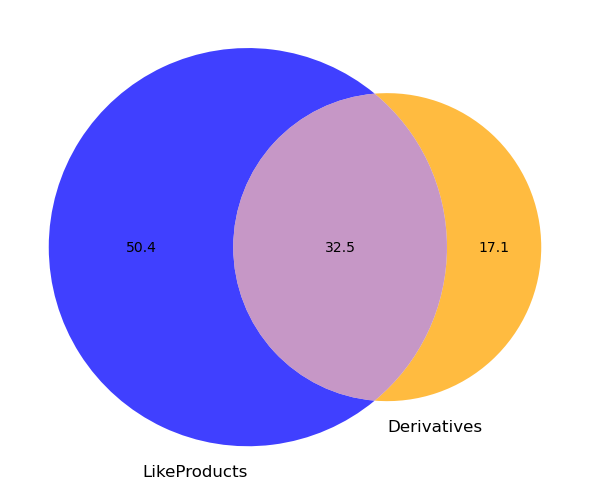

In [29]:
CompLib.cluster_libraries(methodology='samples',
                         lib_names=['LikeProducts','Derivatives'],
                         n_samples=6000,
                         verbose=True) # We pick a number that is larger than the largest number of medoids
CompLib.venn_diagram_composition(lib_names=['LikeProducts','Derivatives'])